In [1]:
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import TPESampler
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. 원천(Raw) 데이터 로드 (기존 병합본 폐기)
# ==========================================
info_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_customer_info.csv')
finance_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_finance_profile.csv')
trans_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_transaction_history.csv')
targets_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_targets.csv')

In [18]:
# 2. RFM 지표 추출 (transaction_history 기준)
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
base_date = pd.to_datetime('2023-12-31')
recent_1m_date = base_date - pd.Timedelta(days=30)

# 1-1. 전체 기간 RFM
rfm_total = trans_df.groupby('customer_id').agg(
    Recency=('trans_date', lambda x: (base_date - x.max()).days),
    Frequency=('trans_id', 'count'),
    Monetary=('trans_amount', 'sum')
).reset_index()

# 1-2. 최근 1달(30일) RFM
recent_df = trans_df[trans_df['trans_date'] >= recent_1m_date]
rfm_recent = recent_df.groupby('customer_id').agg(
    recent_1m_Freq=('trans_id', 'count'),
    recent_1m_Monetary=('trans_amount', 'sum')
).reset_index()

# 병합 및 결측치(최근 1달 결제 없는 사람) 0 처리
rfm_df = rfm_total.merge(rfm_recent, on='customer_id', how='left').fillna(0)

# 🔥 킬러 파생변수 1: 단기 소비 하락률 (Momentum)
# 전체 월평균 소비액 대비 최근 1달 소비액의 비율 (0에 가까울수록 최근 소비가 멈췄다는 뜻)
rfm_df['avg_monthly_Monetary'] = rfm_df['Monetary'] / 6  # 6개월 데이터 기준
rfm_df['spend_drop_ratio'] = rfm_df['recent_1m_Monetary'] / (rfm_df['avg_monthly_Monetary'] + 1e-6)

# 🔥 킬러 파생변수 2: 건당 결제액 (Ticket Size)
rfm_df['avg_ticket_size'] = rfm_df['Monetary'] / (rfm_df['Frequency'] + 1e-6)

In [19]:
# ==============================================================================
# 2. 재무/부채 파생 변수 고도화
# ==============================================================================
finance_df['has_overdue'] = (finance_df['fin_overdue_days'] > 0).astype(int)
finance_df['has_cash_svc'] = (finance_df['card_cash_service_amt'] > 0).astype(int)
finance_df['has_card_loan'] = (finance_df['card_loan_amt'] > 0).astype(int)
finance_df['total_debt'] = finance_df['card_cash_service_amt'] + finance_df['card_loan_amt'] + finance_df['total_loan_balance']

# 🔥 킬러 파생변수 3: 부채 압박 지수 (Debt to Asset Ratio)
# 예금 잔액 대비 총 부채의 비율 (이 수치가 비정상적으로 높으면 한계차주/비자발적 이탈 위험)
finance_df['debt_to_asset_ratio'] = finance_df['total_debt'] / (finance_df['total_deposit_balance'] + 1e-6)

# 자산 변동 추세 구간화
bins = [-np.inf, -2, 0, 2, np.inf]
labels = [3, 2, 1, 0]
finance_df['asset_trend_risk'] = pd.cut(finance_df['fin_asset_trend_score'], bins=bins, labels=labels).astype(int)

In [20]:
# 3. 데이터 병합
df = info_df.merge(rfm_df, on='customer_id', how='left')
df = df.merge(finance_df, on='customer_id', how='left')
df = df.merge(targets_df, on='customer_id', how='inner')


In [21]:
# ==============================================================================
# [STEP 2] 🚨 에러 원인 제거: 범주형 변수를 Category 타입으로 지정 (Label 인코딩 X)
# ==============================================================================
# LightGBM이 알아서 최적의 분할을 찾도록 category 타입으로만 묶어줍니다.
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 학습에 방해되는 날짜 및 타겟 컬럼 제거
drop_cols = ['customer_id', 'target_churn', 'target_ltv', 'join_date', 'trans_date']
features = [col for col in df.columns if col not in drop_cols]

X = df[features]
y = df['target_churn']

In [29]:
# ==============================================================================
# [STEP 3] Train / Valid 분할 (Stratified 적용)
# ==============================================================================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 불균형 데이터 극복을 위한 이탈(1) 클래스 가중치 계산 (약 9배)
scale_weight = ((len(y_train) - y_train.sum()) / y_train.sum()) * 0.7
print(f"✅ 전처리 완료! 조정된 불균형 가중치: {scale_weight:.2f}")

✅ 전처리 완료! 조정된 불균형 가중치: 6.38


In [30]:
# ==============================================================================
# [STEP 4] K-Fold 교차 검증 + Optuna 하이퍼파라미터 최적화
# ==============================================================================
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'scale_pos_weight': scale_weight,  # 🚨 SMOTE 대신 내장 가중치 사용!
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_valid, y_fold_valid = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        # SMOTE 없이 원본 데이터로 바로 학습
        model = lgb.LGBMClassifier(**param)
        model.fit(X_fold_train, y_fold_train)
        
        preds = model.predict_proba(X_fold_valid)[:, 1]
        auc = roc_auc_score(y_fold_valid, preds)
        auc_scores.append(auc)
        
    return np.mean(auc_scores)

print("\n▶️ Optuna 하이퍼파라미터 탐색을 시작합니다...")
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30)  # 필요시 50으로 늘리세요

print(f"\n🥇 Best Trial AUC: {study.best_trial.value:.4f}")

[I 2026-04-12 22:16:10,758] A new study created in memory with name: no-name-111e2cc4-9de9-4216-8514-b7661c4af32c



▶️ Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-04-12 22:16:32,522] Trial 0 finished with value: 0.7699065284945875 and parameters: {'n_estimators': 562, 'learning_rate': 0.044635901521768134, 'max_depth': 8, 'num_leaves': 64, 'min_child_samples': 16}. Best is trial 0 with value: 0.7699065284945875.
[I 2026-04-12 22:16:49,755] Trial 1 finished with value: 0.7927709798098697 and parameters: {'n_estimators': 409, 'learning_rate': 0.00571549193815661, 'max_depth': 9, 'num_leaves': 64, 'min_child_samples': 39}. Best is trial 1 with value: 0.7927709798098697.
[I 2026-04-12 22:16:56,114] Trial 2 finished with value: 0.7904701192402355 and parameters: {'n_estimators': 314, 'learning_rate': 0.04665303012212833, 'max_depth': 8, 'num_leaves': 29, 'min_child_samples': 17}. Best is trial 1 with value: 0.7927709798098697.
[I 2026-04-12 22:17:07,359] Trial 3 finished with value: 0.7952188502352071 and parameters: {'n_estimators': 428, 'learning_rate': 0.010074238942079334, 'max_depth': 6, 'num_leaves': 49, 'min_child_samples': 21}. Best i


🥇 Best Trial AUC: 0.7992


In [31]:
# ==============================================================================
# [STEP 5] 최종 모델 학습 및 평가 리포트
# ==============================================================================
best_params = study.best_params
best_params['scale_pos_weight'] = scale_weight
best_params['random_state'] = 42
best_params['verbose'] = -1

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

valid_preds = final_model.predict_proba(X_valid)[:, 1]
final_auc = roc_auc_score(y_valid, valid_preds)

print("=" * 50)
print(f"🔥 최종 Validation ROC-AUC Score: {final_auc:.4f}")
print("=" * 50)

🔥 최종 Validation ROC-AUC Score: 0.7889


🔍 최종 모델 예측 결과 정밀 분석을 시작합니다...

🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10
-> 실제 이탈(1)인데 확률이 0.01이거나, 유지(0)인데 0.99로 예측한 치명적 오답들입니다.


,Actual_Churn,Predicted_Prob,Error_Gap,age,gender,region_code,is_married,prefer_category
3528,0,0.937604,0.937604,42,F,R03,1,Electronics
29686,0,0.917935,0.917935,28,F,R01,1,Home
16947,0,0.916283,0.916283,46,M,R01,0,Grocery
36156,0,0.916268,0.916268,30,F,R01,0,Home
45425,0,0.914542,0.914542,31,F,R04,1,Fashion
30697,0,0.913787,0.913787,25,F,R01,0,Beauty
31300,0,0.910169,0.910169,27,M,R06,1,Fashion
36705,1,0.095564,0.904436,37,F,R01,0,Beauty
42574,1,0.095753,0.904247,37,M,R01,1,Electronics
38839,1,0.099872,0.900128,47,M,R07,1,Grocery


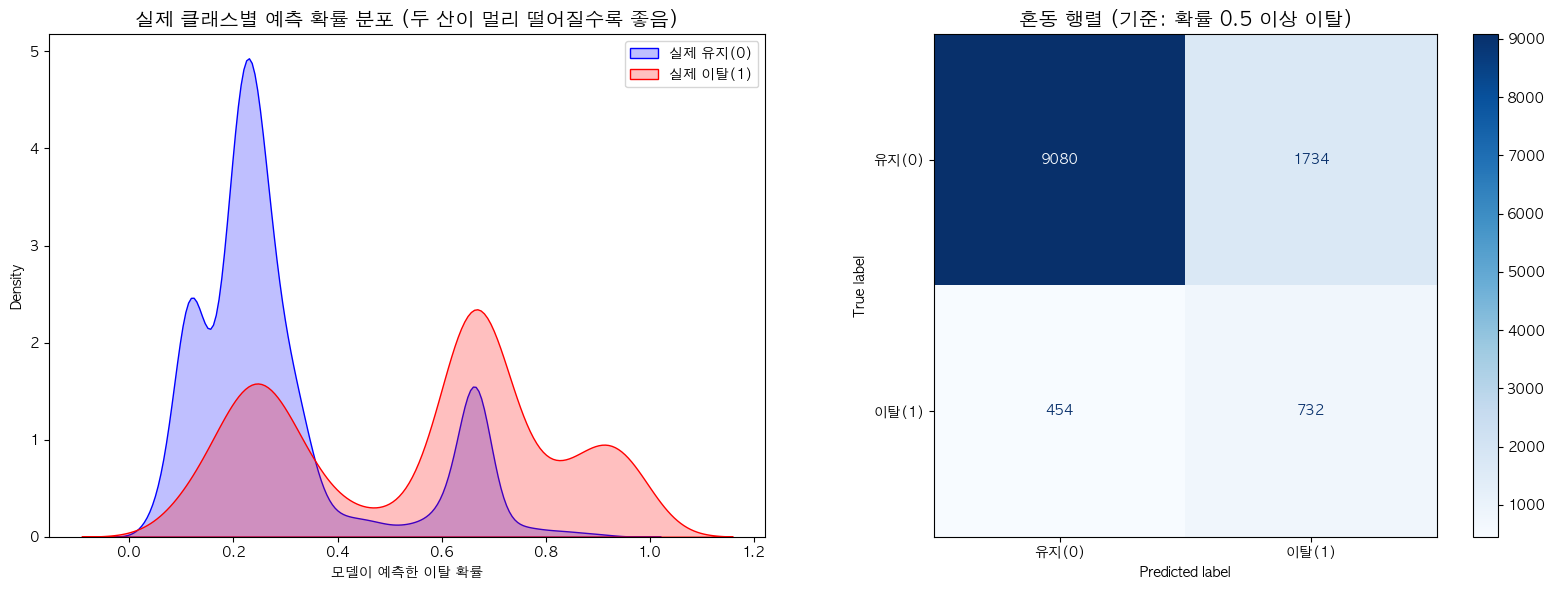

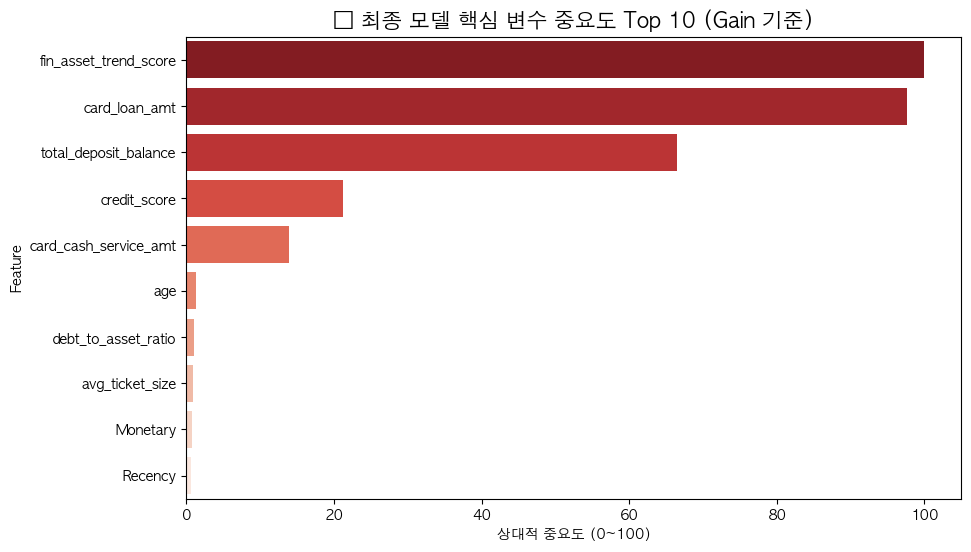

In [32]:
print("🔍 최종 모델 예측 결과 정밀 분석을 시작합니다...\n")

# 한글 폰트 깨짐 방지 (맥OS는 'AppleGothic', 윈도우는 'Malgun Gothic' 사용)
plt.rcParams['font.family'] = 'AppleGothic' # 윈도우라면 'Malgun Gothic'으로 변경!
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 1. 눈으로 직접 확인하는 예측 결과 데이터프레임 만들기
# ==============================================================================
# 검증 데이터(X_valid)에 실제 정답과 예측 확률을 붙입니다.
results_df = X_valid.copy()
results_df['Actual_Churn'] = y_valid
results_df['Predicted_Prob'] = valid_preds

# 예측 오차(Error) 계산: 1에 가까울수록 모델이 완벽하게 헛짚었다는 뜻
results_df['Error_Gap'] = abs(results_df['Actual_Churn'] - results_df['Predicted_Prob'])

print("🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10")
print("-> 실제 이탈(1)인데 확률이 0.01이거나, 유지(0)인데 0.99로 예측한 치명적 오답들입니다.")
worst_cases = results_df.sort_values(by='Error_Gap', ascending=False).head(10)
display(worst_cases[['Actual_Churn', 'Predicted_Prob', 'Error_Gap'] + features[:5]]) # 앞부분 피처만 살짝 보기

# ==============================================================================
# 2. 오차 분석 시각화 (예측 확률 분포도)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 클래스별 예측 확률 분포 (Density Plot)
sns.kdeplot(data=results_df[results_df['Actual_Churn']==0], x='Predicted_Prob', fill=True, color='blue', label='실제 유지(0)', ax=axes[0])
sns.kdeplot(data=results_df[results_df['Actual_Churn']==1], x='Predicted_Prob', fill=True, color='red', label='실제 이탈(1)', ax=axes[0])
axes[0].set_title('실제 클래스별 예측 확률 분포 (두 산이 멀리 떨어질수록 좋음)', fontsize=14)
axes[0].set_xlabel('모델이 예측한 이탈 확률')
axes[0].legend()

# [그래프 2] 혼동 행렬 (임계값 0.5 기준)
THRESHOLD = 0.5
predicted_class = (valid_preds >= THRESHOLD).astype(int)
cm = confusion_matrix(y_valid, predicted_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['유지(0)', '이탈(1)'])
disp.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title(f'혼동 행렬 (기준: 확률 {THRESHOLD} 이상 이탈)', fontsize=14)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. 최종 모델의 피처 중요도 (Gain 기준)
# ==============================================================================
# SMOTE와 Optuna를 거친 최종 모델은 과연 어떤 변수를 보고 판단했을까?
feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': final_model.booster_.feature_importance(importance_type='gain')
})

# 100점 만점으로 스케일링
feature_imp['Importance'] = 100 * (feature_imp['Importance'] / feature_imp['Importance'].max())
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(10), palette='Reds_r')
plt.title('🔥 최종 모델 핵심 변수 중요도 Top 10 (Gain 기준)', fontsize=15)
plt.xlabel('상대적 중요도 (0~100)')
plt.show()